# FIG6: Learned acceleration energy landscape enables accurate and fast forward simulation

This notebook regenerates manuscript Figure 6 from the packaged data archive `FIG6.zip`.
The archive must be in the same folder as this notebook. The notebook saves `FIG6.svg`, `FIG6.pdf` and `FIG6.png`.

Saved FIG6.svg
Saved FIG6.pdf


Saved FIG6.png


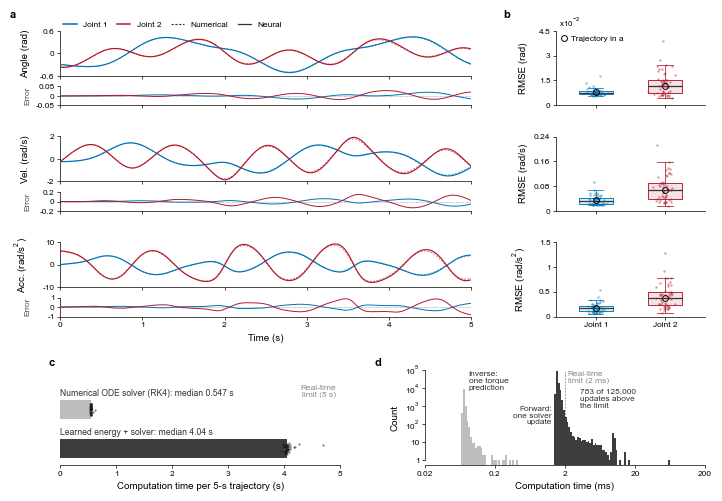

Data provenance:
  demo_trajectory_index = 10 (shown in a, circled in b)
  trajectories = 50
  states_per_trajectory = 2500
  median time per trajectory: numerical ODE solver 0.5475 s, learned energy + solver 4.0429 s (real-time limit 5 s)
  forward latency queries = 125000 (783 above 2 ms)
  inverse latency queries = 10000
Latency summary:
          measurement      n   min_ms    q1_ms  median_ms    q3_ms   p99_ms    max_ms
forward_neural_solver 125000 1.447791 1.521958   1.542375 1.587500 1.907837 60.592334
    inverse_model_16k  10000 0.068417 0.072500   0.073333 0.074208 0.087043  0.402875


In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedFormatter, FixedLocator, FuncFormatter, NullLocator
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Load packaged data. FIG6.zip must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIG6.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIG6")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIG6.zip or FIG6 in the current folder. "
        "Place the data archive in the same folder as FIG6.ipynb."
    )

if DATA_ARCHIVE.is_dir():
    def open_member(name):
        return open(DATA_ARCHIVE / name, "rb")
else:
    _archive = zipfile.ZipFile(DATA_ARCHIVE)

    def open_member(name):
        return _archive.open(name)

with open_member("fig6_arrays.npz") as npz_file:
    packaged = np.load(npz_file)
    arrays = {name: packaged[name] for name in packaged.files if name != "metadata_json"}
rmse_table = pd.read_csv(open_member("fig6_rmse_values.csv"))
timing_table = pd.read_csv(open_member("fig6_trajectory_timing.csv"))
latency_table = pd.read_csv(open_member("fig6_latency_values.csv"))
latency_summary = pd.read_csv(open_member("fig6_latency_summary.csv"))
demo_table = pd.read_csv(open_member("fig6_demo_trajectory.csv"))
metadata = json.load(open_member("fig6_metadata.json"))

# Named arrays used by the figure.
time_s = arrays["time_s"]
true_q = arrays["numerical_position_rad"]
pred_q = arrays["neural_position_rad"]
true_dq = arrays["numerical_velocity_rad_s"]
pred_dq = arrays["neural_velocity_rad_s"]
true_ddq = arrays["numerical_acceleration_rad_s2"]
pred_ddq = arrays["neural_acceleration_rad_s2"]
rmse_pos = arrays["position_rmse_rad"]
rmse_vel = arrays["velocity_rmse_rad_s"]
rmse_acc = arrays["acceleration_rmse_rad_s2"]
times_ode = arrays["trajectory_time_ode_s"]
times_neural = arrays["trajectory_time_neural_solver_s"]
forward_latency_ms = arrays["forward_latency_ms"]
inverse_latency_ms = arrays["inverse_latency_16k_ms"]
demo_idx = int(metadata["demo_trajectory_index"])
trajectory_real_time_s = float(metadata["trajectory_real_time_threshold_s"])
forward_real_time_ms = float(metadata["forward_real_time_threshold_ms"])

# -----------------------------------------------------------------------------
# Style (Nature: 183 mm double column, Arial 5-7 pt, 0.5 pt axes, bold lower-case panel letters).
# Joint colours match the other manuscript figures; timing panels use neutral greys.
# -----------------------------------------------------------------------------
BLUE = "#0072B2"
RED = "#B2182B"
NEUTRAL = "#333333"
LIGHT_NEUTRAL = "#8A8A8A"
GREY_LIGHT = "#BDBDBD"
GREY_DARK = "#3D3D3D"
POINT_DARK = "#1A1A1A"
JOINT_COLORS = [BLUE, RED]
JOINT_LABELS = ["Joint 1", "Joint 2"]
rng = np.random.default_rng(23)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.0,
    "ytick.major.size": 2.0,
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.dpi": 600,
})


def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", direction="out", length=2.0, width=0.5, pad=1.8)
    ax.grid(False)


def add_panel_label(ax, label, dx_in, dy_in):
    # Bold lower-case letter placed dx_in inches left of, and dy_in inches above, the axes,
    # in figure coordinates so that it stays inside the 183 mm canvas.
    figure = ax.figure
    width_in, height_in = figure.get_size_inches()
    box = ax.get_position()
    figure.text(max(box.x0 - dx_in / width_in, 0.006), min(box.y1 + dy_in / height_in, 0.995), label,
                ha="left", va="top", fontsize=8, fontweight="bold", color="black")


def plot_point_series(ax, x_values, y_values, color, markersize=1.6, alpha=0.55, zorder=3):
    # Individual plot calls keep points editable as separate vector markers.
    for x_value, y_value in zip(np.asarray(x_values, dtype=float), np.asarray(y_values, dtype=float)):
        ax.plot([float(x_value)], [float(y_value)], marker="o", linestyle="None",
                markersize=markersize, markerfacecolor=color, markeredgecolor="none",
                alpha=alpha, zorder=zorder, rasterized=False)


def nice_limit(value):
    # Smallest 1, 2 or 5 x 10^k that is >= value (for symmetric, labelled error axes)
    value = float(value)
    exponent = np.floor(np.log10(value))
    for mantissa in (1.0, 2.0, 5.0, 10.0):
        candidate = mantissa * 10.0 ** exponent
        if candidate >= value:
            return candidate
    return 10.0 ** (exponent + 1)


def format_tick(value, _pos=None):
    return f"{value:g}"


# -----------------------------------------------------------------------------
# Panel a: representative rollout (numerical dashed, neural solid) with the signed
# error (neural minus numerical) of the same trajectory underneath each quantity.
# -----------------------------------------------------------------------------
TRACE = slice(None, None, 4)


def plot_rollout_pair(ax_main, ax_err, true_values, pred_values, ylabel, ylim, yticks, err_label):
    t_trace = time_s[TRACE]
    for joint_idx, color in enumerate(JOINT_COLORS):
        ax_main.plot(t_trace, true_values[demo_idx, TRACE, joint_idx], color=color,
                     linestyle=(0, (2.0, 1.45)), linewidth=0.70, alpha=0.60, zorder=2)
        ax_main.plot(t_trace, pred_values[demo_idx, TRACE, joint_idx], color=color,
                     linestyle="-", linewidth=0.85, zorder=3)
        ax_err.plot(t_trace, pred_values[demo_idx, TRACE, joint_idx] - true_values[demo_idx, TRACE, joint_idx],
                    color=color, linestyle="-", linewidth=0.70, zorder=3)
    ax_err.axhline(0.0, color=LIGHT_NEUTRAL, linewidth=0.45, linestyle=(0, (1.4, 1.4)), zorder=1)

    ax_main.set_xlim(float(time_s.min()), float(time_s.max()))
    ax_main.set_ylim(*ylim)
    ax_main.set_yticks(yticks)
    ax_main.yaxis.set_major_formatter(FuncFormatter(format_tick))
    ax_main.set_ylabel(ylabel)
    ax_main.tick_params(labelbottom=False)

    err_limit = nice_limit(np.abs(pred_values[demo_idx] - true_values[demo_idx]).max())
    ax_err.set_xlim(float(time_s.min()), float(time_s.max()))
    ax_err.set_ylim(-err_limit, err_limit)
    ax_err.set_yticks([-err_limit, 0.0, err_limit])
    ax_err.yaxis.set_major_formatter(FuncFormatter(format_tick))
    ax_err.set_ylabel(err_label, fontsize=6, color="#555555")
    ax_err.tick_params(labelbottom=False)
    style_axis(ax_main)
    style_axis(ax_err)


# -----------------------------------------------------------------------------
# Panel b: box plots of the trajectory-wise RMSE per joint with all 50 trajectories
# overlaid as points; the trajectory shown in panel a is circled.
# -----------------------------------------------------------------------------
BOX_POSITIONS = [1.0, 1.72]


def plot_rmse_boxes(ax, values, ylabel, ylim, yticks, scale_note=None):
    boxes = ax.boxplot(
        [values[:, 0], values[:, 1]],
        positions=BOX_POSITIONS,
        widths=0.36,
        whis=1.5,
        showfliers=False,
        patch_artist=True,
        manage_ticks=False,
        capwidths=0.16,
        boxprops={"linewidth": 0.65},
        whiskerprops={"linewidth": 0.55},
        capprops={"linewidth": 0.55},
        medianprops={"color": NEUTRAL, "linewidth": 0.9},
    )
    for joint_idx, color in enumerate(JOINT_COLORS):
        boxes["boxes"][joint_idx].set_facecolor(mpl.colors.to_rgba(color, 0.12))
        boxes["boxes"][joint_idx].set_edgecolor(color)
        for whisker in boxes["whiskers"][2 * joint_idx: 2 * joint_idx + 2]:
            whisker.set_color(color)
        for cap in boxes["caps"][2 * joint_idx: 2 * joint_idx + 2]:
            cap.set_color(color)
        # All trajectories, jittered around the box
        jitter = rng.normal(0.0, 0.045, size=values.shape[0])
        plot_point_series(ax, BOX_POSITIONS[joint_idx] + jitter, values[:, joint_idx], color,
                          markersize=1.7, alpha=0.45, zorder=4)
        # The trajectory shown in panel a
        ax.plot([BOX_POSITIONS[joint_idx]], [float(values[demo_idx, joint_idx])], marker="o",
                linestyle="None", markersize=4.2, markerfacecolor="none", markeredgecolor="black",
                markeredgewidth=0.7, zorder=6)

    ax.set_xlim(0.58, 2.14)
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.set_xticks(BOX_POSITIONS)
    ax.set_xticklabels([])
    ax.set_ylabel(ylabel)
    if scale_note:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"{value / 1e-2:g}"))
        ax.text(0.02, 1.02, scale_note, transform=ax.transAxes, ha="left", va="bottom", fontsize=5.8)
    else:
        ax.yaxis.set_major_formatter(FuncFormatter(format_tick))
    style_axis(ax)


# -----------------------------------------------------------------------------
# Panel c: computation time per 5-s trajectory (bar = median, points = trajectories).
# -----------------------------------------------------------------------------
def draw_timing_bars(ax, series, limit_s, limit_label):
    n_series = len(series)
    y_positions = np.arange(n_series)[::-1].astype(float)
    bar_height = 0.48
    for (label, values, color), y in zip(series, y_positions):
        values = np.asarray(values, dtype=float)
        median = float(np.median(values))
        ax.barh(y, median, height=bar_height, color=color, edgecolor="none", zorder=1)
        jitter = rng.uniform(-0.30, 0.30, size=values.size) * bar_height
        plot_point_series(ax, values, y + jitter, POINT_DARK, markersize=1.6, alpha=0.55, zorder=3)
        ax.text(0.0, y + bar_height / 2 + 0.06, f"{label}: median {median:.3g} s",
                ha="left", va="bottom", fontsize=6.2, color=NEUTRAL)
    ax.axvline(limit_s, color=LIGHT_NEUTRAL, linewidth=0.6, linestyle=(0, (2.2, 1.6)), zorder=0)
    ax.text(limit_s - 0.015 * limit_s, y_positions[0] + bar_height / 2 + 0.06, limit_label,
            ha="right", va="bottom", fontsize=6, color=LIGHT_NEUTRAL, linespacing=1.1)
    ax.set_xlim(0.0, limit_s)
    ax.set_ylim(-0.42, y_positions[0] + 1.0)
    ticks = np.arange(0.0, limit_s + 0.5, 1.0)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{v:g}" for v in ticks])
    ax.set_yticks([])
    ax.set_xlabel("Computation time per 5-s trajectory (s)")
    style_axis(ax)
    ax.spines["left"].set_visible(False)


# -----------------------------------------------------------------------------
# Panel d: per-query latency histograms (log-spaced bins, log counts).
# -----------------------------------------------------------------------------
def draw_latency_histograms(ax, series, limit_ms, bins_per_decade=40):
    all_values = np.concatenate([np.asarray(values, dtype=float) for _, values, _ in series])
    x_low = 0.02
    x_high = 20.0 if all_values.max() <= 20.0 else 200.0
    n_bins = int(round(bins_per_decade * np.log10(x_high / x_low)))
    edges = np.logspace(np.log10(x_low), np.log10(x_high), n_bins + 1)
    y_low, y_high = 0.55, 1e5
    for _, values, color in series:
        counts, _ = np.histogram(np.asarray(values, dtype=float), bins=edges)
        keep = counts > 0
        ax.bar(edges[:-1][keep], counts[keep] - y_low, width=np.diff(edges)[keep], bottom=y_low,
               align="edge", color=color, edgecolor="none", linewidth=0, zorder=2)
    ax.axvline(limit_ms, color=LIGHT_NEUTRAL, linewidth=0.6, linestyle=(0, (2.2, 1.6)), zorder=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(x_low, x_high)
    ax.set_ylim(y_low, y_high)
    x_ticks = [tick for tick in (0.02, 0.2, 2.0, 20.0, 200.0) if tick <= x_high]
    ax.xaxis.set_major_locator(FixedLocator(x_ticks))
    ax.xaxis.set_major_formatter(FixedFormatter([f"{tick:g}" for tick in x_ticks]))
    ax.xaxis.set_minor_locator(NullLocator())
    y_ticks = [1.0, 10.0, 1e2, 1e3, 1e4, 1e5]
    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax.yaxis.set_major_formatter(FixedFormatter(["1", "10", "10$^{2}$", "10$^{3}$", "10$^{4}$", "10$^{5}$"]))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.set_xlabel("Computation time (ms)")
    ax.set_ylabel("Count")
    style_axis(ax)
    # The axis line starts at the first labelled tick (count = 1); bins with a single
    # query appear as short stubs between the axis bottom and that tick.
    ax.spines["left"].set_bounds(1.0, y_high)
    ax.spines["bottom"].set_bounds(x_low, x_high)
    return edges


# -----------------------------------------------------------------------------
# Figure layout: a (rollout + error) and b (RMSE) on top, c (timing) and d (latency) below.
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(7.20, 5.05), constrained_layout=False)
outer = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[3.0, 1.0],
    left=0.082,
    right=0.978,
    top=0.935,
    bottom=0.075,
    hspace=0.28,
)
gs_top = outer[0].subgridspec(nrows=1, ncols=2, width_ratios=[2.75, 1.0], wspace=0.30)
gs_a = gs_top[0].subgridspec(nrows=8, ncols=1,
                             height_ratios=[1.0, 0.42, 0.22, 1.0, 0.42, 0.22, 1.0, 0.42], hspace=0.40)
gs_b = gs_top[1].subgridspec(nrows=3, ncols=1, hspace=0.42)
gs_bottom = outer[1].subgridspec(nrows=1, ncols=2, width_ratios=[1.0, 1.0], wspace=0.30)

ax_a1 = fig.add_subplot(gs_a[0, 0])
ax_e1 = fig.add_subplot(gs_a[1, 0], sharex=ax_a1)
ax_a2 = fig.add_subplot(gs_a[3, 0], sharex=ax_a1)
ax_e2 = fig.add_subplot(gs_a[4, 0], sharex=ax_a1)
ax_a3 = fig.add_subplot(gs_a[6, 0], sharex=ax_a1)
ax_e3 = fig.add_subplot(gs_a[7, 0], sharex=ax_a1)
ax_b1 = fig.add_subplot(gs_b[0, 0])
ax_b2 = fig.add_subplot(gs_b[1, 0], sharex=ax_b1)
ax_b3 = fig.add_subplot(gs_b[2, 0], sharex=ax_b1)
ax_c = fig.add_subplot(gs_bottom[0, 0])
ax_d = fig.add_subplot(gs_bottom[0, 1])

plot_rollout_pair(ax_a1, ax_e1, true_q, pred_q, "Angle (rad)", (-0.6, 0.6), [-0.6, 0.0, 0.6], "Error")
plot_rollout_pair(ax_a2, ax_e2, true_dq, pred_dq, "Vel. (rad/s)", (-2.0, 2.0), [-2.0, 0.0, 2.0], "Error")
plot_rollout_pair(ax_a3, ax_e3, true_ddq, pred_ddq, "Acc. (rad/s$^2$)", (-10.0, 10.0), [-10.0, 0.0, 10.0], "Error")
ax_e3.tick_params(labelbottom=True)
ax_e3.set_xticks([0, 1, 2, 3, 4, 5])
ax_e3.set_xlabel("Time (s)")
fig.align_ylabels([ax_a1, ax_e1, ax_a2, ax_e2, ax_a3, ax_e3])

legend_handles = [
    Line2D([0], [0], color=BLUE, linewidth=1.1, label="Joint 1"),
    Line2D([0], [0], color=RED, linewidth=1.1, label="Joint 2"),
    Line2D([0], [0], color=NEUTRAL, linewidth=0.8, linestyle=(0, (2.0, 1.45)), label="Numerical"),
    Line2D([0], [0], color=NEUTRAL, linewidth=0.9, linestyle="-", label="Neural"),
]
ax_a1.legend(handles=legend_handles, loc="lower left", bbox_to_anchor=(0.0, 1.0), ncol=4,
             frameon=False, handlelength=1.6, columnspacing=1.1, borderaxespad=0.0)
add_panel_label(ax_a1, "a", dx_in=0.50, dy_in=0.21)

plot_rmse_boxes(ax_b1, rmse_pos, "RMSE (rad)", (0.0, 0.045), [0.0, 0.015, 0.030, 0.045], "x10$^{-2}$")
plot_rmse_boxes(ax_b2, rmse_vel, "RMSE (rad/s)", (0.0, 0.24), [0.0, 0.08, 0.16, 0.24])
plot_rmse_boxes(ax_b3, rmse_acc, "RMSE (rad/s$^2$)", (0.0, 1.5), [0.0, 0.5, 1.0, 1.5])
ax_b3.set_xticklabels(JOINT_LABELS)
fig.align_ylabels([ax_b1, ax_b2, ax_b3])
for upper_rmse_ax in (ax_b1, ax_b2):
    upper_rmse_ax.tick_params(labelbottom=False)
ax_b1.legend(
    handles=[Line2D([0], [0], marker="o", linestyle="None", markersize=4.2, markerfacecolor="none",
                    markeredgecolor="black", markeredgewidth=0.7, label="Trajectory in a")],
    loc="upper left", frameon=False, handlelength=1.0, handletextpad=0.4, borderaxespad=0.1,
)
add_panel_label(ax_b1, "b", dx_in=0.52, dy_in=0.21)

draw_timing_bars(
    ax_c,
    [
        ("Numerical ODE solver (RK4)", times_ode, GREY_LIGHT),
        ("Learned energy + solver", times_neural, GREY_DARK),
    ],
    limit_s=trajectory_real_time_s,
    limit_label=f"Real-time\nlimit ({trajectory_real_time_s:g} s)",
)
add_panel_label(ax_c, "c", dx_in=0.12, dy_in=0.12)

forward_vals = forward_latency_ms[np.isfinite(forward_latency_ms) & (forward_latency_ms > 0)]
inverse_vals = inverse_latency_ms[np.isfinite(inverse_latency_ms) & (inverse_latency_ms > 0)]
n_forward_above = int((forward_vals > forward_real_time_ms).sum())
draw_latency_histograms(
    ax_d,
    [
        ("inverse", inverse_vals, GREY_LIGHT),
        ("forward", forward_vals, GREY_DARK),
    ],
    limit_ms=forward_real_time_ms,
)
ax_d.text(0.085, 9e4, "Inverse:\none torque\nprediction",
          ha="left", va="top", fontsize=6, color=NEUTRAL, linespacing=1.1)
ax_d.text(float(forward_vals.min()) * 0.90, 3e2, "Forward:\none solver\nupdate",
          ha="right", va="center", fontsize=6, color=NEUTRAL, linespacing=1.1)
ax_d.text(forward_real_time_ms * 1.10, 9e4, f"Real-time\nlimit ({forward_real_time_ms:g} ms)",
          ha="left", va="top", fontsize=6, color=LIGHT_NEUTRAL, linespacing=1.1)
ax_d.text(forward_real_time_ms * 1.65, 2.5e3,
          f"{n_forward_above:,} of {forward_vals.size:,}\nupdates above\nthe limit",
          ha="left", va="center", fontsize=6, color=NEUTRAL, linespacing=1.1)
add_panel_label(ax_d, "d", dx_in=0.50, dy_in=0.12)

for ext in ["svg", "pdf", "png"]:
    path = Path(f"FIG6.{ext}")
    # Exported at the canvas size (183 mm wide); all artists are placed inside the canvas.
    if ext == "png":
        fig.savefig(path, dpi=600, facecolor="white")
    else:
        fig.savefig(path, facecolor="white")
    print(f"Saved {path}")

plt.show()

print("Data provenance:")
print(f"  demo_trajectory_index = {demo_idx} (shown in a, circled in b)")
print(f"  trajectories = {metadata['num_trajectories']}")
print(f"  states_per_trajectory = {metadata['states_per_trajectory']}")
print(f"  median time per trajectory: numerical ODE solver {np.median(times_ode):.4f} s, "
      f"learned energy + solver {np.median(times_neural):.4f} s (real-time limit {trajectory_real_time_s:g} s)")
print(f"  forward latency queries = {forward_vals.size} ({n_forward_above} above {forward_real_time_ms:g} ms)")
print(f"  inverse latency queries = {inverse_vals.size}")
print("Latency summary:")
print(latency_summary.to_string(index=False))